# HW2 Playground

Fill in TODOs as you work through the assignment.
Implement the required sections in `model.py`, and use this notebook to orchestrate and run your solution.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from hw2_loader import HW2DataLoader
from model import GradientBoostingModel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
# TODO: Load both datasets
loader = HW2DataLoader()

# Heart disease dataset
heart_path = Path('data/heart.csv')
X_heart, y_heart = loader.get_heart_disease_data(csv_path=heart_path)
print(X_heart.shape, y_heart.value_counts().to_dict())

full_heart = pd.concat([X_heart, y_heart], axis=1)
print(f"Duplicate rows before dedup: {full_heart.duplicated().sum()}")
full_heart= full_heart.drop_duplicates().reset_index(drop=True)
X_heart =full_heart.drop(columns=[y_heart.name])
y_heart = full_heart[y_heart.name]
print(f"Shape after dedup: {X_heart.shape}")

# Cancer genomics dataset
cancer_path = Path('data/cancer_genomics.csv')
labels_path = Path('data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(
    csv_path=cancer_path, labels_path=labels_path
)
print(X_cancer.shape, y_cancer.value_counts().to_dict())

Successfully loaded heart disease data with 1025 rows
(1025, 13) {1: 526, 0: 499}
Duplicate rows before dedup: 723
Shape after dedup: (302, 13)
(801, 5479) {'BRCA': 300, 'KIRC': 146, 'LUAD': 141, 'PRAD': 136, 'COAD': 78}


In [6]:
# Train and evaluate heart dataset WITHOUT scaler
model_heart = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=False)
X_train_h ,X_test_h, y_train_h, y_test_h = model_heart.train_test_split(X_heart, y_heart)
model_heart.fit(X_train_h, y_train_h)
metrics_no_scaler = model_heart.evaluate(X_test_h, y_test_h)
print("Heart (no scaler):", metrics_no_scaler)

# Train and evaluate heart dataset WITH scaler
model_heart_scaled = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=True)
model_heart_scaled.train_test_split(X_heart, y_heart) 
model_heart_scaled.fit(X_train_h, y_train_h)
metrics_scaler = model_heart_scaled.evaluate(X_test_h, y_test_h)
print("Heart (scaler):   ", metrics_scaler)

Model trained with 100 estimators
Heart (no scaler): {'accuracy': 0.8032786885245902, 'precision': 0.7575757575757576, 'recall': 0.8620689655172413, 'f1': 0.8064516129032258, 'roc_auc': 0.8405172413793104}
Model trained with 100 estimators
Heart (scaler):    {'accuracy': 0.8032786885245902, 'precision': 0.7575757575757576, 'recall': 0.8620689655172413, 'f1': 0.8064516129032258, 'roc_auc': 0.8405172413793104}


In [7]:
# Cross-validation on heart dataset (no scaler vs scaler)
for use_scaler in [False, True]:
    label="scaler" if use_scaler else "no scaler"
    m = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=use_scaler)
    cv_results = m.cross_validate(X_heart, y_heart, cv=5)
    print(f"\nHeart CV ({label})")
    for metric, result in cv_results.items():
        print(f"  {metric}: mean={result['mean']:.4f}, std={result['std']:.4f}")


Heart CV (no scaler)
  accuracy: mean=0.8045, std=0.0575
  precision_weighted: mean=0.8051, std=0.0579
  recall_weighted: mean=0.8045, std=0.0575
  f1_weighted: mean=0.8034, std=0.0582
  roc_auc_ovr_weighted: mean=0.8815, std=0.0479

Heart CV (scaler)
  accuracy: mean=0.8045, std=0.0575
  precision_weighted: mean=0.8051, std=0.0579
  recall_weighted: mean=0.8045, std=0.0575
  f1_weighted: mean=0.8034, std=0.0582
  roc_auc_ovr_weighted: mean=0.8824, std=0.0479


In [8]:
# Experiment with different depths and ensemble sizes (heart)
results_heart =[]
for depth in [1, 3, 5]:
    for n_est in [50, 100, 200]:
        m =GradientBoostingModel(task='classification', max_depth=depth, learning_rate=0.1, n_estimators=n_est)
        m.train_test_split(X_heart, y_heart)
        m.fit(X_train_h, y_train_h, verbose=False)
        met = m.evaluate(X_test_h, y_test_h)
        met['max_depth'] = depth
        met['n_estimators'] = n_est
        results_heart.append(met)

results_heart_df = pd.DataFrame(results_heart)
print(results_heart_df.to_string(index=False))

 accuracy  precision   recall       f1  roc_auc  max_depth  n_estimators
 0.868852   0.818182 0.931034 0.870968 0.910560          1            50
 0.836066   0.771429 0.931034 0.843750 0.891164          1           100
 0.786885   0.735294 0.862069 0.793651 0.883621          1           200
 0.786885   0.735294 0.862069 0.793651 0.845905          3            50
 0.803279   0.757576 0.862069 0.806452 0.840517          3           100
 0.819672   0.781250 0.862069 0.819672 0.836207          3           200
 0.786885   0.750000 0.827586 0.786885 0.850216          5            50
 0.770492   0.727273 0.827586 0.774194 0.837284          5           100
 0.786885   0.750000 0.827586 0.786885 0.817888          5           200


In [9]:
# Hyperparameter tuning (heart)
param_grid = {
    'max_depth': [2, 3, 5],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
}
tuning_heart= model_heart.tune_hyperparameters(X_heart, y_heart, param_grid, cv=3)
print("Best params:",tuning_heart['best_params'])
print("Best ROC AUC:", tuning_heart['best_score'])

Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 50}
Best ROC AUC: 0.8995364270726589


 max_depth  n_estimators  learning_rate  mean_score  std_score
         2            50           0.10    0.899536   0.037135
         2            50           0.20    0.899107   0.032988
         2           200           0.01    0.898968   0.036605
         2           100           0.01    0.895032   0.044211
         2           100           0.10    0.894247   0.027747
         3           200           0.01    0.893766   0.042349
         3           100           0.01    0.889393   0.041341
         3            50           0.10    0.888011   0.036604
         2           100           0.20    0.886993   0.024135
         2           200           0.10    0.884863   0.024545
         5           100           0.10    0.883019   0.029490
         5            50           0.20    0.882130   0.023770
         5           100           0.20    0.881420   0.027135
         3           100           0.10    0.880637   0.031189
         5           200           0.10    0.880196   0

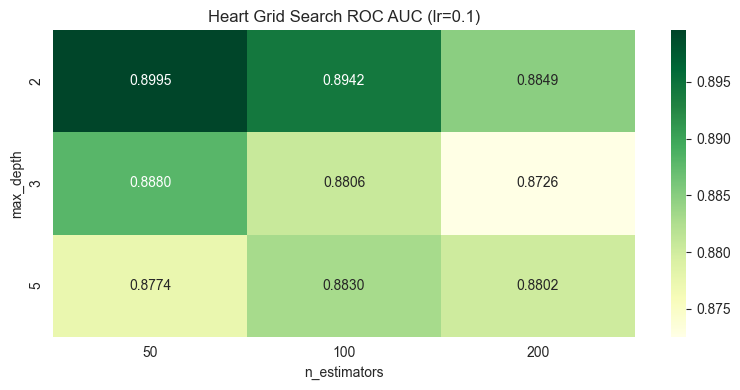

In [10]:
cv_df =tuning_heart['cv_results'][['param_max_depth','param_n_estimators','param_learning_rate','mean_test_score','std_test_score']].copy()
cv_df.columns = ['max_depth','n_estimators','learning_rate','mean_score','std_score']
cv_df = cv_df.sort_values('mean_score', ascending=False)
print(cv_df.to_string(index=False))

best_lr = tuning_heart['best_params']['learning_rate']
heatmap_df = cv_df[cv_df['learning_rate'] == best_lr].pivot(index='max_depth', columns='n_estimators', values='mean_score')
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df,annot=True, fmt='.4f', cmap='YlGn')
plt.title(f'Heart Grid Search ROC AUC (lr={best_lr})')
plt.tight_layout()
plt.show()

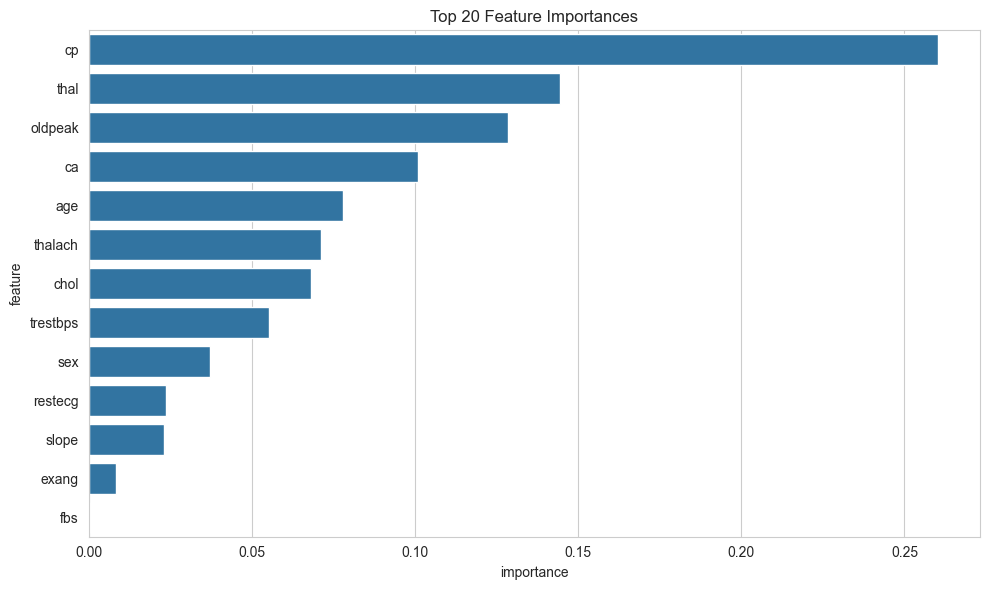

    feature  importance
0        cp    0.260126
1      thal    0.144332
2   oldpeak    0.128671
3        ca    0.101093
4       age    0.077851
5   thalach    0.071346
6      chol    0.068270
7  trestbps    0.055428
8       sex    0.037357
9   restecg    0.023621


In [11]:
# Feature importance (heart)
heart_importance = model_heart.get_feature_importance(plot=True)
print(heart_importance.head(10))

In [12]:
# Train and evaluate cancer dataset WITHOUT scaler
cancer_model = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=False)
X_train_c, X_test_c, y_train_c, y_test_c = cancer_model.train_test_split(X_cancer, y_cancer)
cancer_model.fit(X_train_c, y_train_c)
cancer_metrics_no_scaler = cancer_model.evaluate(X_test_c, y_test_c)
print("Cancer (no scaler):", cancer_metrics_no_scaler)

# Train and evaluate cancer dataset WITH scaler
cancer_model_scaled= GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=True)
cancer_model_scaled.train_test_split(X_cancer, y_cancer)
cancer_model_scaled.fit(X_train_c, y_train_c)
cancer_metrics_scaler = cancer_model_scaled.evaluate(X_test_c, y_test_c)
print("Cancer (scaler):   ", cancer_metrics_scaler)

Model trained with 100 estimators
Cancer (no scaler): {'accuracy': 0.9813664596273292, 'precision': 0.9827742568201709, 'recall': 0.9813664596273292, 'f1': 0.9812285864247688, 'roc_auc': 1.0}
Model trained with 100 estimators
Cancer (scaler):    {'accuracy': 0.9813664596273292, 'precision': 0.9827742568201709, 'recall': 0.9813664596273292, 'f1': 0.9812285864247688, 'roc_auc': 1.0}


In [13]:
# Cross-validation on cancer dataset (no scaler vs scaler)
for use_scaler in [False, True]:
    label = "scaler" if use_scaler else "no scaler"
    m = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100, use_scaler=use_scaler)
    cv_results_c = m.cross_validate(X_cancer, y_cancer, cv=3)
    print(f"\nCancer CV ({label})")
    for metric, result in cv_results_c.items():
        print(f"  {metric}: mean={result['mean']:.4f}, std={result['std']:.4f}")


Cancer CV (no scaler)
  accuracy: mean=0.9875, std=0.0124
  precision_weighted: mean=0.9880, std=0.0118
  recall_weighted: mean=0.9875, std=0.0124
  f1_weighted: mean=0.9874, std=0.0125
  roc_auc_ovr_weighted: mean=0.9999, std=0.0001

Cancer CV (scaler)
  accuracy: mean=0.9875, std=0.0124
  precision_weighted: mean=0.9880, std=0.0118
  recall_weighted: mean=0.9875, std=0.0124
  f1_weighted: mean=0.9874, std=0.0125
  roc_auc_ovr_weighted: mean=0.9999, std=0.0001


In [14]:
# Experiment with different depths and ensemble sizes (cancer)
results_cancer = []
for depth in [1, 3, 5]:
    for n_est in [50, 100, 200]:
        m = GradientBoostingModel(task='classification', max_depth=depth, learning_rate=0.1, n_estimators=n_est)
        m.train_test_split(X_cancer, y_cancer)
        m.fit(X_train_c, y_train_c, verbose=False)
        met = m.evaluate(X_test_c, y_test_c)
        met['max_depth'] = depth
        met['n_estimators'] = n_est
        results_cancer.append(met)

results_cancer_df = pd.DataFrame(results_cancer)
print(results_cancer_df.to_string(index=False))

 accuracy  precision   recall       f1  roc_auc  max_depth  n_estimators
 0.987578   0.988885 0.987578 0.987701 1.000000          1            50
 0.981366   0.984161 0.981366 0.981846 0.999906          1           100
 0.981366   0.984161 0.981366 0.981846 0.998965          1           200
 0.993789   0.993889 0.993789 0.993760 0.999891          3            50
 0.981366   0.982774 0.981366 0.981229 1.000000          3           100
 1.000000   1.000000 1.000000 1.000000 1.000000          3           200
 0.981366   0.982774 0.981366 0.981229 0.999844          5            50
 0.981366   0.982774 0.981366 0.981229 0.999953          5           100
 1.000000   1.000000 1.000000 1.000000 1.000000          5           200


In [15]:
# Hyperparameter tuning (cancer). weighted scoring for multi-class
param_grid_c = {
    'max_depth': [2, 3],
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
}
tuning_cancer = cancer_model.tune_hyperparameters(
    X_cancer, y_cancer, param_grid_c, cv=3, scoring='roc_auc_ovr_weighted'
)
print("Best params:", tuning_cancer['best_params'])
print("Best ROC AUC (weighted):", tuning_cancer['best_score'])

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Best ROC AUC (weighted): 0.9998656457257237


 max_depth  n_estimators  learning_rate  mean_score  std_score
         3            50           0.10    0.999866   0.000056
         2           100           0.10    0.999858   0.000129
         3           100           0.10    0.999858   0.000086
         2            50           0.10    0.999847   0.000121
         2            50           0.05    0.999808   0.000154
         2           100           0.05    0.999808   0.000154
         3           100           0.05    0.999805   0.000010
         3            50           0.05    0.999768   0.000060


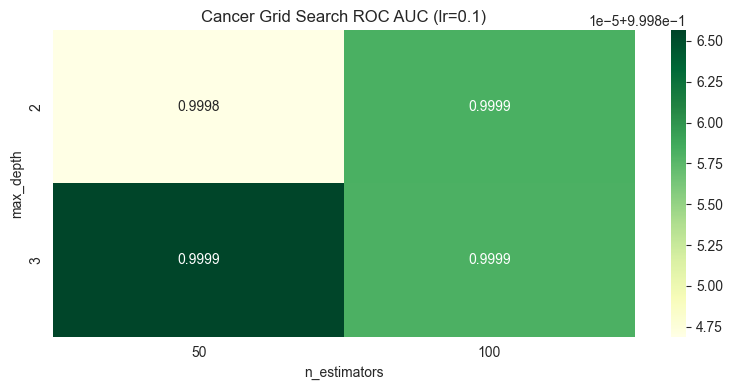

In [16]:
cv_df_c = tuning_cancer['cv_results'][['param_max_depth','param_n_estimators','param_learning_rate','mean_test_score','std_test_score']].copy()
cv_df_c.columns = ['max_depth','n_estimators','learning_rate','mean_score','std_score']
cv_df_c = cv_df_c.sort_values('mean_score', ascending=False)
print(cv_df_c.to_string(index=False))

best_lr_c = tuning_cancer['best_params']['learning_rate']
heatmap_df_c = cv_df_c[cv_df_c['learning_rate'] == best_lr_c].pivot(index='max_depth', columns='n_estimators', values='mean_score')
plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df_c, annot=True, fmt='.4f', cmap='YlGn')
plt.title(f'Cancer Grid Search ROC AUC (lr={best_lr_c})')
plt.tight_layout()
plt.show()

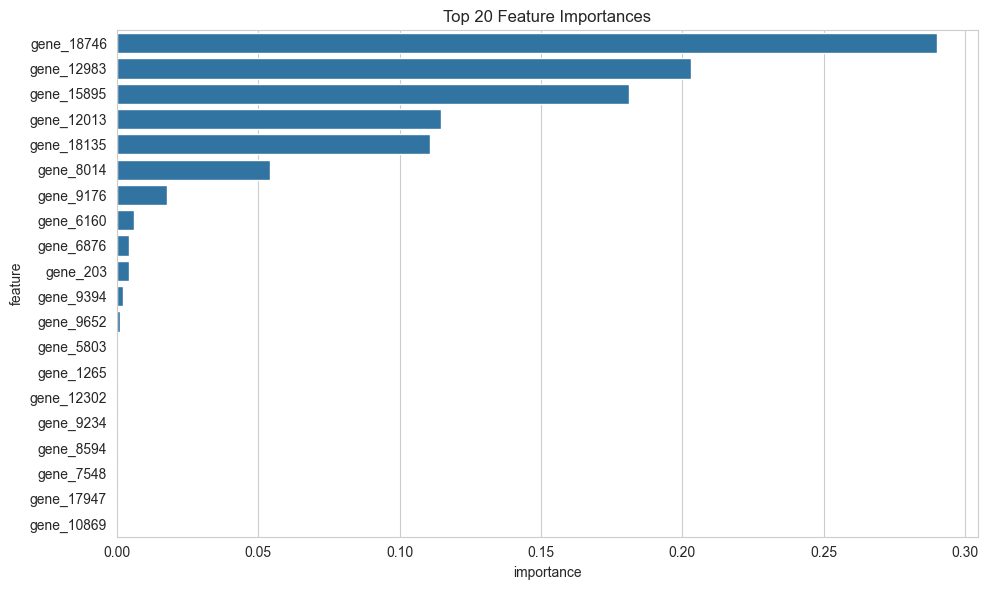

       feature  importance
0   gene_18746    0.289857
1   gene_12983    0.202906
2   gene_15895    0.181102
3   gene_12013    0.114788
4   gene_18135    0.110769
5    gene_8014    0.054029
6    gene_9176    0.017862
7    gene_6160    0.006123
8    gene_6876    0.004364
9     gene_203    0.004243
10   gene_9394    0.002161
11   gene_9652    0.001227
12   gene_5803    0.000583
13   gene_1265    0.000499
14  gene_12302    0.000485
15   gene_9234    0.000485
16   gene_8594    0.000484
17   gene_7548    0.000482
18  gene_17947    0.000481
19  gene_10869    0.000377


In [17]:
# Feature importance (cancer)
cancer_importance = cancer_model.get_feature_importance(plot=True, top_n=20)
print(cancer_importance.head(20))

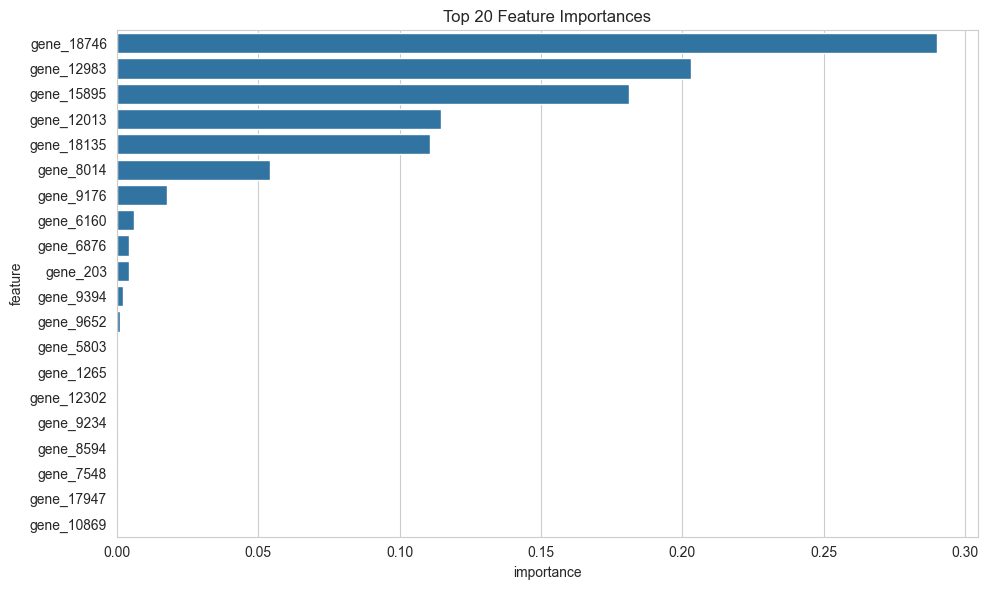


Total features: 5479
       feature  importance
0   gene_18746    0.289857
1   gene_12983    0.202906
2   gene_15895    0.181102
3   gene_12013    0.114788
4   gene_18135    0.110769
5    gene_8014    0.054029
6    gene_9176    0.017862
7    gene_6160    0.006123
8    gene_6876    0.004364
9     gene_203    0.004243
10   gene_9394    0.002161
11   gene_9652    0.001227
12   gene_5803    0.000583
13   gene_1265    0.000499
14  gene_12302    0.000485
15   gene_9234    0.000485
16   gene_8594    0.000484
17   gene_7548    0.000482
18  gene_17947    0.000481
19  gene_10869    0.000377


In [18]:

from pathlib import Path
import numpy as np, pandas as pd
from hw2_loader import HW2DataLoader
from model import GradientBoostingModel

loader = HW2DataLoader()
cancer_path  = Path('data/cancer_genomics.csv')
labels_path  = Path('data/labels_cancer_genomics.csv')
X_cancer, y_cancer = loader.get_cancer_genomics_data(csv_path=cancer_path, labels_path=labels_path)

# Train a GB classifier on the full cancer dataset to extract feature importances
gb = GradientBoostingModel(task='classification', max_depth=3, learning_rate=0.1, n_estimators=100)
X_tr, X_te, y_tr, y_te = gb.train_test_split(X_cancer, y_cancer)
gb.fit(X_tr, y_tr, verbose=False)

# Get feature importances from the GB model
gb_importance = gb.get_feature_importance(plot=True, top_n=20)
print(f"\nTotal features: {X_cancer.shape[1]}")
print(gb_importance.head(20))

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y_cancer)

# Top features from GB importance (cell 13)
gb_top = [
    'gene_18746','gene_12983','gene_15895','gene_12013','gene_18135',
    'gene_8014','gene_9176','gene_6160','gene_6876','gene_203',
    'gene_9394','gene_9652','gene_5803','gene_1265','gene_12302',
    'gene_9234','gene_8594','gene_7548','gene_17947','gene_10869',
]

def hw1_pipe():
    return Pipeline([('scaler', StandardScaler()),
                     ('lr', LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42))])

# Full feature set
scores_all = cross_val_score(hw1_pipe(), X_cancer, y_enc, cv=5, scoring='accuracy')
print(f"Full features ({X_cancer.shape[1]}): acc = {scores_all.mean():.4f} ± {scores_all.std():.4f}")

# Reduced top-K feature sets
for k in [5, 10, 20]:
    scores_k = cross_val_score(hw1_pipe(), X_cancer[gb_top[:k]], y_enc, cv=5, scoring='accuracy')
    print(f"Top-{k} GB features:    acc = {scores_k.mean():.4f} ± {scores_k.std():.4f}")

Full features (5479): acc = 0.9988 ± 0.0025
Top-5 GB features:    acc = 0.9900 ± 0.0030
Top-10 GB features:    acc = 0.9963 ± 0.0031
Top-20 GB features:    acc = 0.9988 ± 0.0025
